# Imports and functions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

np.random.seed(0)
tf.random.set_seed(0)

plt.style.use("dark_background")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# ============================================================
# Helper: cosine-similarity histogram on FIXED PAIRS
# ============================================================
def make_fixed_pairs(y, n_pairs=20000, seed=0):
    """
    Make a fixed list of (i,j) index pairs on a label vector y.
    We also return a boolean mask 'same' indicating whether labels match.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    N = len(y)

    # sample i != j uniformly
    i = rng.integers(0, N, size=n_pairs)
    j = rng.integers(0, N, size=n_pairs)
    bad = (i == j)
    while bad.any():
        j[bad] = rng.integers(0, N, size=bad.sum())
        bad = (i == j)

    same = (y[i] == y[j])
    return i, j, same

def pairwise_cos_sims(Z, i, j):
    """
    Compute cosine similarities for pairs (i,j) using embeddings Z.
    """
    Z = Z.astype(np.float32)
    Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)  # L2 normalize
    sims = np.sum(Z[i] * Z[j], axis=1)
    return sims

def plot_pair_hist(sims, same_mask, title="", bins=40):
    sims_same = sims[same_mask]
    sims_diff = sims[~same_mask]

    plt.figure(figsize=(8, 3))
    plt.hist(sims_same, bins=bins, alpha=0.65, label="same class")
    plt.hist(sims_diff, bins=bins, alpha=0.65, label="diff class")
    plt.title(title)
    plt.xlabel("cosine similarity")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Load images

X shape: (1000, 64, 64, 1) y shape: (1000,)
Class counts: {0: 500, 1: 500}


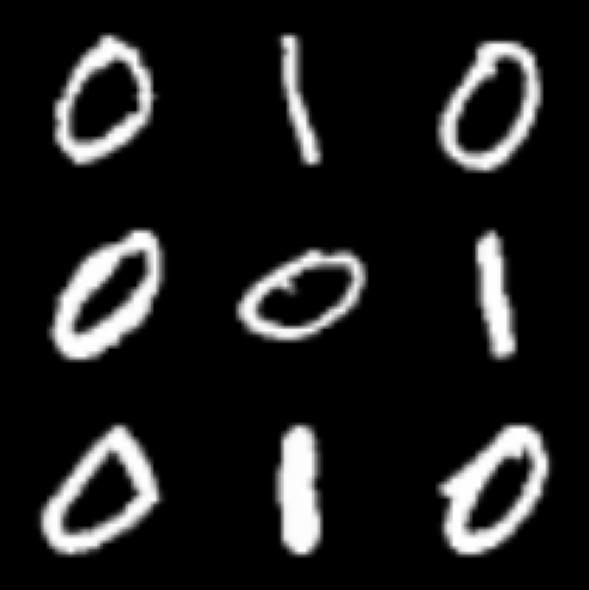

In [2]:
data_folder = "C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/Images/"
eng_file = "digit_char_dataset.csv"

df_all = pd.read_csv(os.path.join(data_folder, eng_file))
df_all = df_all.rename(columns={"class": "char"}).astype(int)

classes = np.arange(2)         # digits 0 and 1 (edit as desired)
n_samp_per_class = 500         # per class

dfs = []
for c in classes:
    dfs.append(df_all[df_all["char"] == c].sample(n_samp_per_class, random_state=0))
df_sub = pd.concat(dfs).reset_index(drop=True)

X_28 = df_sub.iloc[:, :-1].to_numpy().reshape(-1, 28, 28).astype(np.float32)
y = df_sub["char"].to_numpy().astype(int)

# resize to 64x64 + normalize
X = np.array([cv2.resize(img, (64, 64)) for img in X_28], dtype=np.float32) / 255.0
X = X[..., None]

print("X shape:", X.shape, "y shape:", y.shape)
print("Class counts:", pd.Series(y).value_counts().sort_index().to_dict())

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# show random grid of images (kept)
m, n = 3, 3
fig, axes = plt.subplots(m, n, figsize=(n * 2, m * 2))
for i in range(m):
    for j in range(n):
        idx = np.random.randint(0, len(X_train))
        axes[i, j].imshow(X_train[idx, :, :, 0], cmap="gray")
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

# Build and train autoencoder model

In [3]:
latent_dim = 32

def make_autoencoder(input_shape=(64, 64, 1), latent_dim=32):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, strides=2, padding="same")(inp)   # 32x32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)     # 16x16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)    # 8x8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)    # 4x4
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.1)(x)
    z = layers.Dense(latent_dim, name="z")(x)

    encoder = keras.Model(inp, z, name="encoder")

    z_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(4 * 4 * 256)(z_in)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Reshape((4, 4, 256))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)  # 8x8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)   # 16x16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)   # 32x32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2DTranspose(16, 3, strides=2, padding="same")(x)   # 64x64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    out = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)

    decoder = keras.Model(z_in, out, name="decoder")
    autoencoder = keras.Model(inp, decoder(encoder(inp)), name="autoencoder")
    return encoder, decoder, autoencoder

encoder_ae, decoder_ae, autoencoder = make_autoencoder((64, 64, 1), latent_dim=latent_dim)
autoencoder.summary()

autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=64,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Functional)                 │ (None, 32)                  │       1,446,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Functional)                 │ (None, 64, 64, 1)           │         528,193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,975,009 (7.53 MB)

 Trainable params: 1,973,569 (7.53 MB)

 Non-trainable params: 1,440 (5.62 KB)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.1549 - val_loss: 0.2104
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0595 - val_loss: 0.1889
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0361 - val_loss: 0.1701
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0252 - val_loss: 0.1547
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0191 - val_loss: 0.1381
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0144 - val_loss: 0.1232
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0114 - val_loss: 0.1105
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0096 - val_loss: 0.0987
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0086 - val_loss: 0.0884
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0080 - val_loss: 0.0816
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0075 - val_loss: 0.0760
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0

# View sample image, its embedding, and reconstructed image

Embedding (latent vector):
[  6.902  -2.165  -2.772   1.202  -0.493  19.773   5.904   2.243   5.051   7.550  -3.608  16.765   4.466  -6.793  -6.557   8.845  -8.623  -7.069  10.890   1.882   6.527  -0.380  -0.798  -4.313
   9.090  -4.376 -14.847   3.310 -10.088 -14.298  -1.818  -2.253]


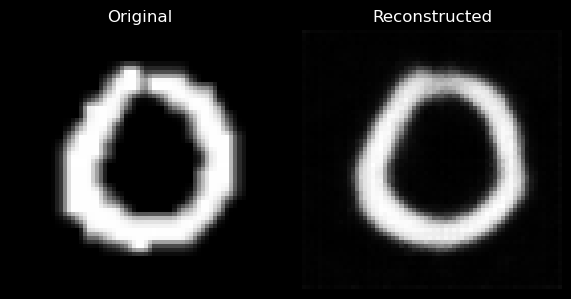

In [4]:
# pick an example from validation set
idx = 0  # change this to pick a different one
x = X_val[idx:idx+1]  # keep batch dimension (1,64,64,1)

# encode + decode
z = encoder_ae.predict(x, verbose=0)          # (1, latent_dim)
x_hat = decoder_ae.predict(z, verbose=0)      # (1,64,64,1)

# print embedding nicely
np.set_printoptions(precision=3, suppress=True, floatmode="fixed", linewidth=200)
print("Embedding (latent vector):")
print(z[0])

# plot original and reconstruction side-by-side
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(x[0, :, :, 0], cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(x_hat[0, :, :, 0], cmap="gray")
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# View multiple decoded images

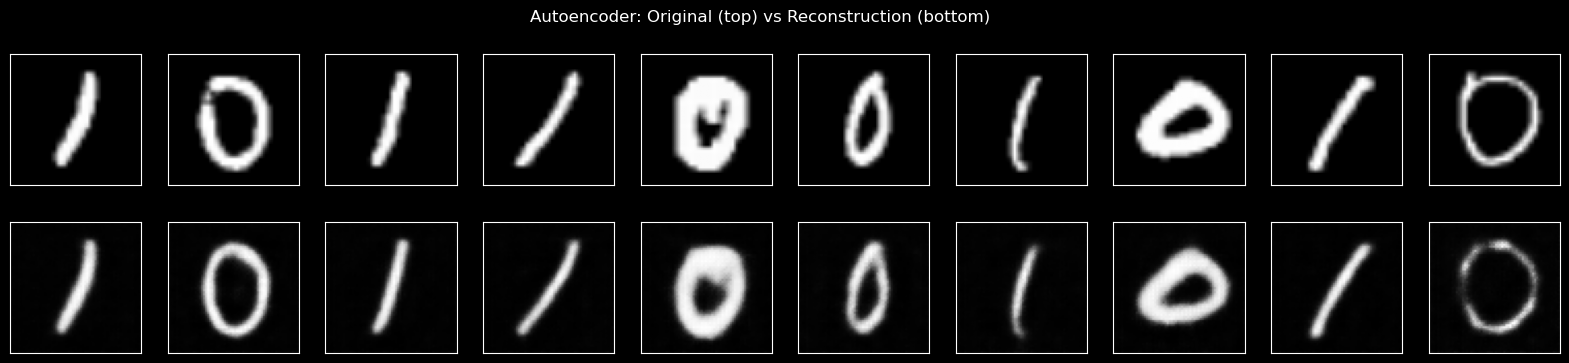

In [5]:
decoded_imgs = autoencoder.predict(X_val, batch_size=128, verbose=0)

n_show = 10
plt.figure(figsize=(20, 4))
for i in range(1, n_show + 1):
    ax = plt.subplot(2, n_show, i)
    plt.imshow(X_val[i, :, :, 0], cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n_show, i + n_show)
    plt.imshow(decoded_imgs[i, :, :, 0], cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Autoencoder: Original (top) vs Reconstruction (bottom)")
plt.show()

# Create new images from random embeddings

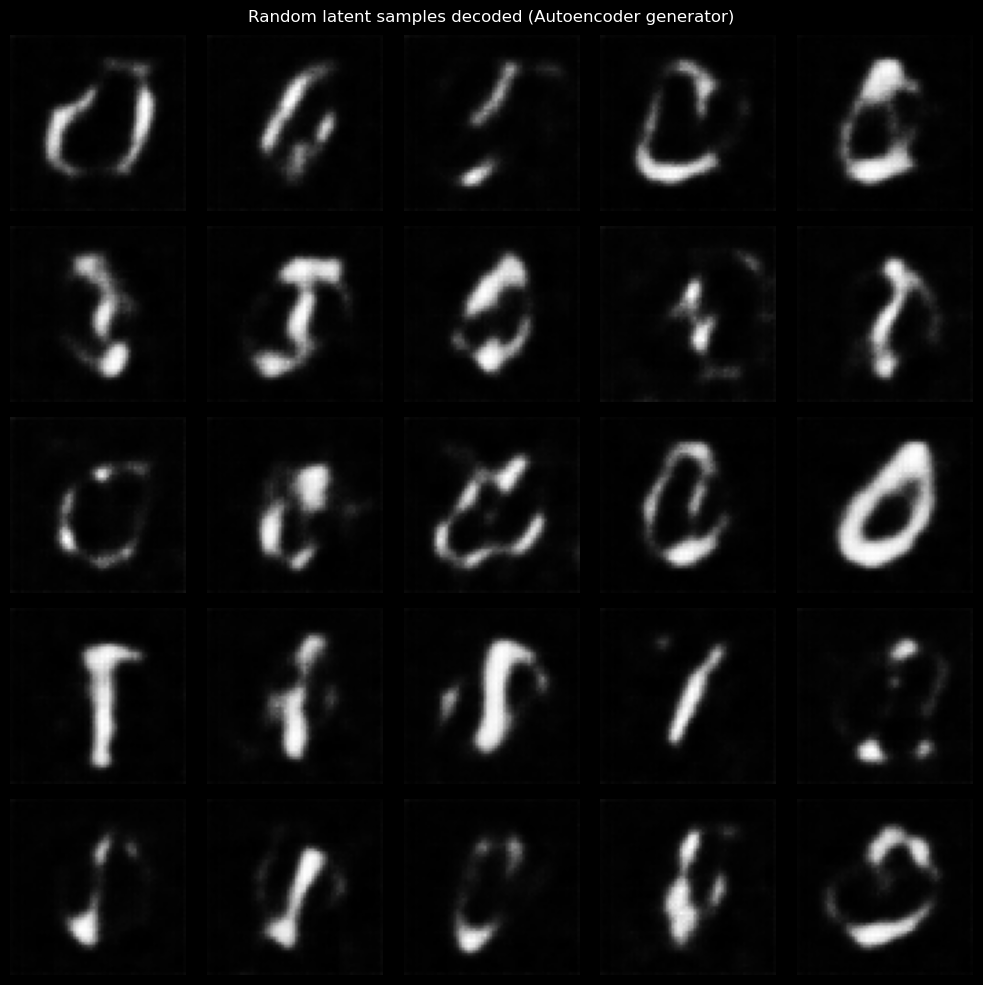

In [6]:
Z_train = encoder_ae.predict(X_train, batch_size=128, verbose=0)
mu = Z_train.mean(axis=0)
sd = Z_train.std(axis=0) + 1e-6

n_gen = 25
Z_rand = np.random.normal(mu, sd, size=(n_gen, latent_dim)).astype(np.float32)
X_gen = decoder_ae.predict(Z_rand, verbose=0)

m, n = 5, 5
fig, axes = plt.subplots(m, n, figsize=(n * 2, m * 2))
for i in range(m):
    for j in range(n):
        idx = i * n + j
        axes[i, j].imshow(X_gen[idx, :, :, 0], cmap="gray")
        axes[i, j].axis("off")
plt.suptitle("Random latent samples decoded (Autoencoder generator)")
plt.tight_layout()
plt.show()

# View PCA components and cosine similarity of pairs of similar/different class images

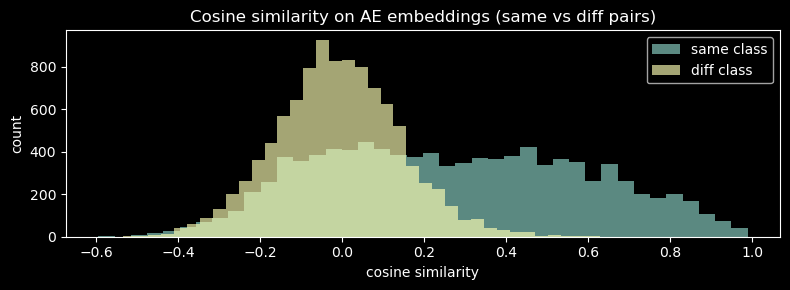

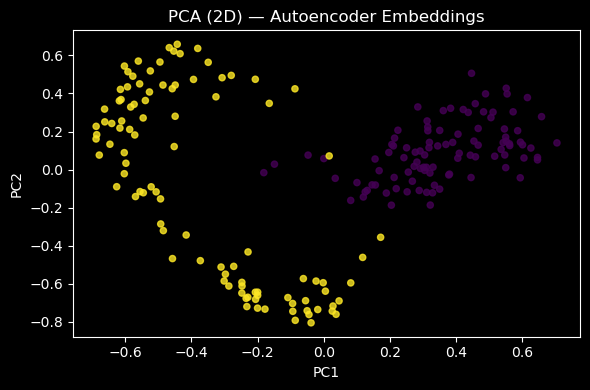

In [7]:
Z_val_ae = encoder_ae.predict(X_val, batch_size=128, verbose=0)

# fixed pairs to reuse later
pair_i, pair_j, pair_same = make_fixed_pairs(y_val, n_pairs=20000, seed=123)

# AE similarity histogram (two colors: same vs diff)
sims_ae = pairwise_cos_sims(Z_val_ae, pair_i, pair_j)
plot_pair_hist(sims_ae, pair_same, title="Cosine similarity on AE embeddings (same vs diff pairs)", bins=40)

# AE PCA (2D)
Zae = Z_val_ae.astype(float)
Zae = Zae / (np.linalg.norm(Zae, axis=1, keepdims=True) + 1e-9)
pca_ae_2d = PCA(n_components=2, random_state=0).fit_transform(Zae)

plt.figure(figsize=(6, 4))
plt.scatter(pca_ae_2d[:, 0], pca_ae_2d[:, 1], c=y_val, s=20, alpha=0.8)
plt.title("PCA (2D) — Autoencoder Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Build and train a siamese network

In [8]:
embed_dim = 32

def make_siamese_encoder(input_shape=(64,64,1), embed_dim=32):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, strides=2, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.1)(x)

    emb = layers.Dense(embed_dim)(x)
    emb = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1), name="l2norm")(emb)
    return keras.Model(inp, emb, name="siamese_encoder")

def make_pairs_for_training(X, y, n_pairs=20000, seed=0):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    idx_by_class = {c: np.where(y == c)[0] for c in np.unique(y)}
    classes_ = sorted(idx_by_class.keys())

    X1 = np.zeros((n_pairs, *X.shape[1:]), dtype=np.float32)
    X2 = np.zeros((n_pairs, *X.shape[1:]), dtype=np.float32)
    labels = np.zeros((n_pairs,), dtype=np.float32)

    half = n_pairs // 2

    for k in range(half):
        c = rng.choice(classes_)
        a, b = rng.choice(idx_by_class[c], size=2, replace=False)
        X1[k] = X[a]
        X2[k] = X[b]
        labels[k] = 1.0

    for k in range(half, n_pairs):
        c1, c2 = rng.choice(classes_, size=2, replace=False)
        a = rng.choice(idx_by_class[c1])
        b = rng.choice(idx_by_class[c2])
        X1[k] = X[a]
        X2[k] = X[b]
        labels[k] = 0.0

    perm = rng.permutation(n_pairs)
    return X1[perm], X2[perm], labels[perm]

def contrastive_loss(margin=0.7):
    def loss(y_true, d):
        y_true = tf.cast(y_true, tf.float32)
        pos = y_true * tf.square(d)
        neg = (1.0 - y_true) * tf.square(tf.maximum(margin - d, 0.0))
        return tf.reduce_mean(pos + neg)
    return loss

siamese_encoder = make_siamese_encoder((64,64,1), embed_dim=embed_dim)

x1 = keras.Input(shape=(64,64,1))
x2 = keras.Input(shape=(64,64,1))
e1 = siamese_encoder(x1)
e2 = siamese_encoder(x2)
dist = layers.Lambda(lambda t: tf.norm(t[0] - t[1], axis=1, keepdims=True))([e1, e2])

siamese = keras.Model([x1, x2], dist, name="siamese")
siamese.summary()

X1_tr, X2_tr, ypair_tr = make_pairs_for_training(X_train, y_train, n_pairs=12000, seed=0)
X1_va, X2_va, ypair_va = make_pairs_for_training(X_val, y_val, n_pairs=4000, seed=1)

siamese.compile(optimizer=keras.optimizers.Adam(1e-3), loss=contrastive_loss(margin=0.7))

cb2 = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

siamese.fit(
    [X1_tr, X2_tr], ypair_tr,
    validation_data=([X1_va, X2_va], ypair_va),
    epochs=50,
    batch_size=128,
    shuffle=True,
    callbacks=cb2,
    verbose=1
)

Model: "siamese"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 64, 64, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_4 (InputLayer)    │ (None, 64, 64, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ siamese_encoder (Functional)  │ (None, 32)                │       1,446,816 │ input_layer_3[0][0],       │
│                               │                           │                 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 1)                 │               0 │ siamese_encoder[0][0],     │
│                               │                           │                 │ siamese_encoder[1][0]      │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,446,816 (5.52 MB)

 Trainable params: 1,445,856 (5.52 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.0320 - val_loss: 0.1322
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - loss: 3.7922e-04 - val_loss: 0.0135
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 1.3790e-04 - val_loss: 9.7255e-04
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - loss: 7.4071e-05 - val_loss: 6.4222e-04
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - loss: 4.7863e-05 - val_loss: 6.2318e-04
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 3.4382e-05 - val_loss: 6.1665e-04
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 2.6333e-05 - val_loss: 6.0988e-04
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - loss: 2.1014e-05 - val_loss: 6.0356e-04
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - loss: 1.7304e-05 - val_loss: 5.9583e-04
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 1.4559e-05 - val_loss: 5.8946e-04
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss:

# Compare cosine similarity of autoencoder and siamese network embeddings

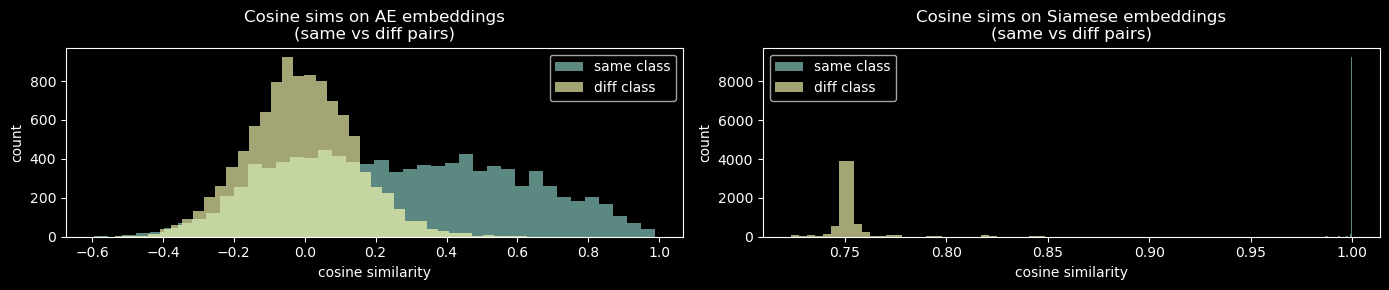

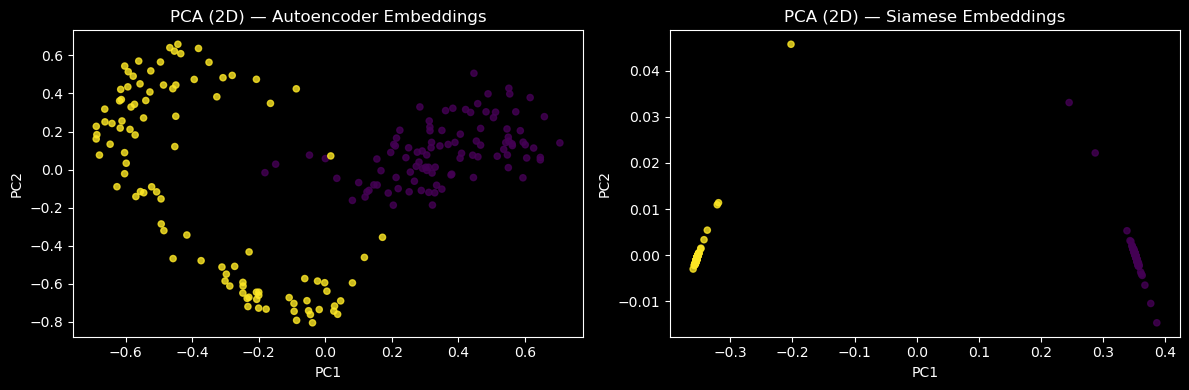

In [9]:
Z_val_siam = siamese_encoder.predict(X_val, batch_size=128, verbose=0)

# --- side-by-side PAIR similarity histograms (AE vs Siamese), using SAME (i,j) pairs ---
sims_siam = pairwise_cos_sims(Z_val_siam, pair_i, pair_j)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# AE hist
axes[0].hist(sims_ae[pair_same], bins=40, alpha=0.65, label="same class")
axes[0].hist(sims_ae[~pair_same], bins=40, alpha=0.65, label="diff class")
axes[0].set_title("Cosine sims on AE embeddings\n(same vs diff pairs)")
axes[0].set_xlabel("cosine similarity")
axes[0].set_ylabel("count")
axes[0].legend()

# Siamese hist
axes[1].hist(sims_siam[pair_same], bins=40, alpha=0.65, label="same class")
axes[1].hist(sims_siam[~pair_same], bins=40, alpha=0.65, label="diff class")
axes[1].set_title("Cosine sims on Siamese embeddings\n(same vs diff pairs)")
axes[1].set_xlabel("cosine similarity")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- PCA side-by-side (AE vs Siamese) ---
Zsi = Z_val_siam.astype(float)
Zsi = Zsi / (np.linalg.norm(Zsi, axis=1, keepdims=True) + 1e-9)

pca_si_2d = PCA(n_components=2, random_state=0).fit_transform(Zsi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

axes[0].scatter(pca_ae_2d[:, 0], pca_ae_2d[:, 1], c=y_val, s=20, alpha=0.8)
axes[0].set_title("PCA (2D) — Autoencoder Embeddings")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(pca_si_2d[:, 0], pca_si_2d[:, 1], c=y_val, s=20, alpha=0.8)
axes[1].set_title("PCA (2D) — Siamese Embeddings")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()